# 📝 Week 3: Peringkasan Teks Bahasa Inggris (Text Summarization)

Notebook ini mendemonstrasikan teknik **peringkasan teks otomatis** menggunakan metode **TF-IDF** pada teks berbahasa Inggris.

## 📚 Tujuan Pembelajaran

1. Memahami konsep peringkasan teks (text summarization) berbasis ekstraktif
2. Melakukan tokenisasi kalimat menggunakan NLTK
3. Menerapkan TF-IDF untuk menghitung bobot kata dalam kalimat
4. Menghitung skor kalimat berdasarkan rata-rata TF-IDF
5. Menentukan threshold untuk memilih kalimat penting
6. Menghasilkan ringkasan dari teks asli

## 1) Import Library

In [1]:
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import pandas as pd

nltk.download('punkt_tab', quiet=True)

print('✅ Semua library berhasil di-import!')

✅ Semua library berhasil di-import!


## 2) Definisi Dokumen

Dokumen yang digunakan adalah artikel berita berbahasa Inggris tentang **Manchester City** memenangkan **Club World Cup**.

In [2]:
document = """
Manchester City makes history by winning Club World Cup

Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.

Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola's side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.

The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.

"We've shown over the past 12 months we are the best team in the world. Our results prove that and the consistency we have managed has been amazing," club captain Kyle Walker said after the game, per Sky Sports.

"To win these five trophies \u2013 for me, the five biggest prizes available to us \u2013 is incredible. I am so proud to have been a part of this and I can honestly say it's an honour to play alongside these players. I couldn't ask for better teammates."

It took just 40 seconds for Manchester City to take the lead.

Brazilian left-back Marcelo miscued a pass in the opening exchanges which let Nathan Ak\u00e9 free to shoot from distance. The defender's effort cannoned back off the post but forward Juli\u00e1n \u00c1lvarez was in the right place to turn the rebound into the net with his chest.

City continued to look dangerous and doubled its lead before the break after Phil Foden's attempted cross was deflected into his own net by Fluminense defender Nino.

Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.

The rout was completed in the 88th minute when \u00c1lvarez capped off a brilliant performance with a clinical finish into the far corner.

City's defence was largely untested for during the game, underlining the team's dominance during this unforgettable year.

"As a manager it is what I am most proud of; that we are always there. No matter how much we win, no matter what trophies we lift, we are there again to fight for the next one," City boss Guardiola said after the match, according to Sky Sports.

"To win the Treble was truly special, but to win two more trophies and now hold these five major titles shows the unique mentality of this team, of the Club and its fans.

"It is something no other English team has ever achieved, and we will always remember this incredible time we spent together."

The game ended in some unsavoury scenes as a scuffle broke out between players on the pitch after the final whistle, but the game will be remembered as yet another successful night for City.

The champion heads back to England where it faces a tough title defence in the Premier League.

It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.
"""

print('📌 DOKUMEN ASLI:')
print('=' * 80)
print(document.strip())
print('=' * 80)
print(f'📊 Panjang dokumen: {len(document.split())} kata')

📌 DOKUMEN ASLI:
Manchester City makes history by winning Club World Cup

Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.

Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola's side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.

The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.

"We've shown over the past 12 months we are the best team in the world. Our results prove that and the consistency we have managed has been amazing," club captain Kyle Walker said after the game, per Sky Sports.

"To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this and I can honestly say it's an honour to play alongside these players. I couldn't a

## 3) Tokenisasi Kalimat

Pada tahap ini, dokumen akan dipecah menjadi kalimat-kalimat menggunakan `sent_tokenize` dari NLTK.

In [3]:
sent_tokens = sent_tokenize(document)

print('📌 HASIL TOKENISASI KALIMAT:')
print('=' * 80)
for i, sent in enumerate(sent_tokens):
    print(f'  Kalimat {i + 1}: {sent}')
    print('-' * 80)
print(f'\n📊 Jumlah kalimat: {len(sent_tokens)}')

📌 HASIL TOKENISASI KALIMAT:
  Kalimat 1: 
Manchester City makes history by winning Club World Cup

Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.
--------------------------------------------------------------------------------
  Kalimat 2: Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola's side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.
--------------------------------------------------------------------------------
  Kalimat 3: The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.
--------------------------------------------------------------------------------
  Kalimat 4: "We've shown over the past 12 months we are the best team in the world.
--------------------------------------------------------

## 4) Vektorisasi TF-IDF

Setiap kalimat akan diubah menjadi vektor TF-IDF. Stopwords bahasa Inggris akan dihapus secara otomatis oleh `TfidfVectorizer`.

In [4]:
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(sent_tokens)

feature_names = vectorizer.get_feature_names_out()

print('✅ TF-IDF Vectorizer berhasil dilatih!')
print(f'📊 Ukuran matriks TF-IDF: {tfidf_matrix.shape}')
print(f'   - Jumlah kalimat : {tfidf_matrix.shape[0]}')
print(f'   - Jumlah kata unik: {tfidf_matrix.shape[1]}')

print('\n📌 Contoh fitur (kata) dalam vocabulary:')
print(feature_names[:20])

✅ TF-IDF Vectorizer berhasil dilatih!
📊 Ukuran matriks TF-IDF: (22, 183)
   - Jumlah kalimat : 22
   - Jumlah kata unik: 183

📌 Contoh fitur (kata) dalam vocabulary:
['12' '40' '72nd' '88th' 'according' 'achieved' 'aké' 'alongside'
 'amazing' 'arabia' 'ask' 'attempted' 'available' 'best' 'better'
 'biggest' 'boasts' 'boss' 'brazilian' 'break']


📌 NILAI TF-IDF KALIMAT PERTAMA:
       Kata   TF-IDF
        cup 0.378512
      world 0.378512
 manchester 0.342656
       club 0.314843
       city 0.256263
     friday 0.214524
    history 0.214524
dismantling 0.214524
    winning 0.214524
      makes 0.214524
     trophy 0.214524
     capped 0.189256
 fluminense 0.189256
 incredible 0.171328
       year 0.171328
        win 0.157422


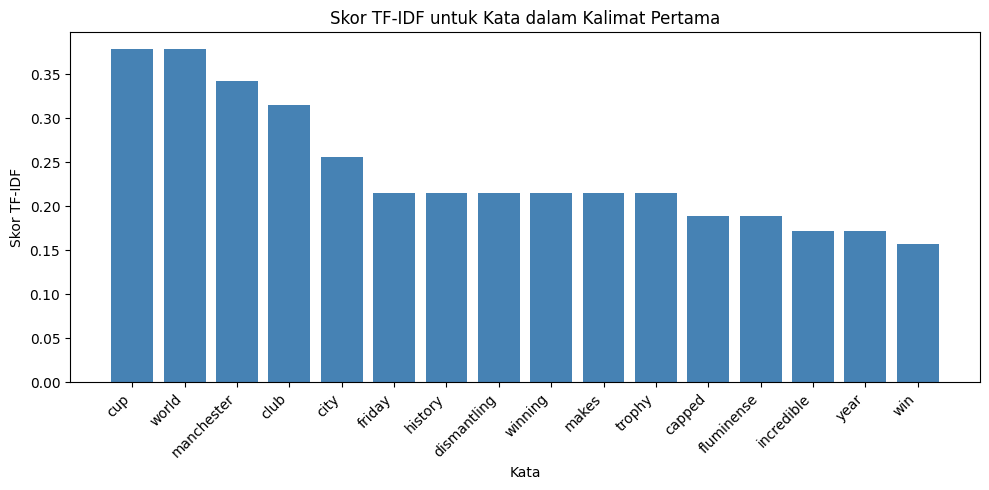

In [5]:
# Menampilkan TF-IDF untuk kalimat pertama
def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
    """Mengembalikan DataFrame TF-IDF untuk kalimat tertentu."""
    values = tfidf_matrix[sentence_index].toarray().flatten()
    df = pd.DataFrame({'Kata': feature_names, 'TF-IDF': values})
    df = df[df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
    return df

df_first = get_tfidf_for_sentence(tfidf_matrix, 0, feature_names)

print('📌 NILAI TF-IDF KALIMAT PERTAMA:')
print('=' * 80)
print(df_first.to_string(index=False))

# Visualisasi
plt.figure(figsize=(10, 5))
plt.bar(df_first['Kata'], df_first['TF-IDF'], color='steelblue')
plt.xlabel('Kata')
plt.ylabel('Skor TF-IDF')
plt.title('Skor TF-IDF untuk Kata dalam Kalimat Pertama')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5) Hitung Skor Kalimat

Skor setiap kalimat dihitung dari **rata-rata nilai TF-IDF** kata-kata yang ada di dalamnya. Kalimat dengan skor lebih tinggi dianggap lebih penting.

📌 SKOR RATA-RATA TF-IDF SETIAP KALIMAT:
  Kalimat 1:
    🔹 Jumlah TF-IDF  : 3.8365
    🔹 Jumlah kata     : 16
    🔹 Skor rata-rata  : 0.2398
--------------------------------------------------------------------------------
  Kalimat 2:
    🔹 Jumlah TF-IDF  : 4.2079
    🔹 Jumlah kata     : 19
    🔹 Skor rata-rata  : 0.2215
--------------------------------------------------------------------------------
  Kalimat 3:
    🔹 Jumlah TF-IDF  : 3.7144
    🔹 Jumlah kata     : 14
    🔹 Skor rata-rata  : 0.2653
--------------------------------------------------------------------------------
  Kalimat 4:
    🔹 Jumlah TF-IDF  : 2.8156
    🔹 Jumlah kata     : 8
    🔹 Skor rata-rata  : 0.3519
--------------------------------------------------------------------------------
  Kalimat 5:
    🔹 Jumlah TF-IDF  : 3.5897
    🔹 Jumlah kata     : 13
    🔹 Skor rata-rata  : 0.2761
--------------------------------------------------------------------------------
  Kalimat 6:
    🔹 Jumlah TF-IDF  : 2.4253
    🔹 Ju

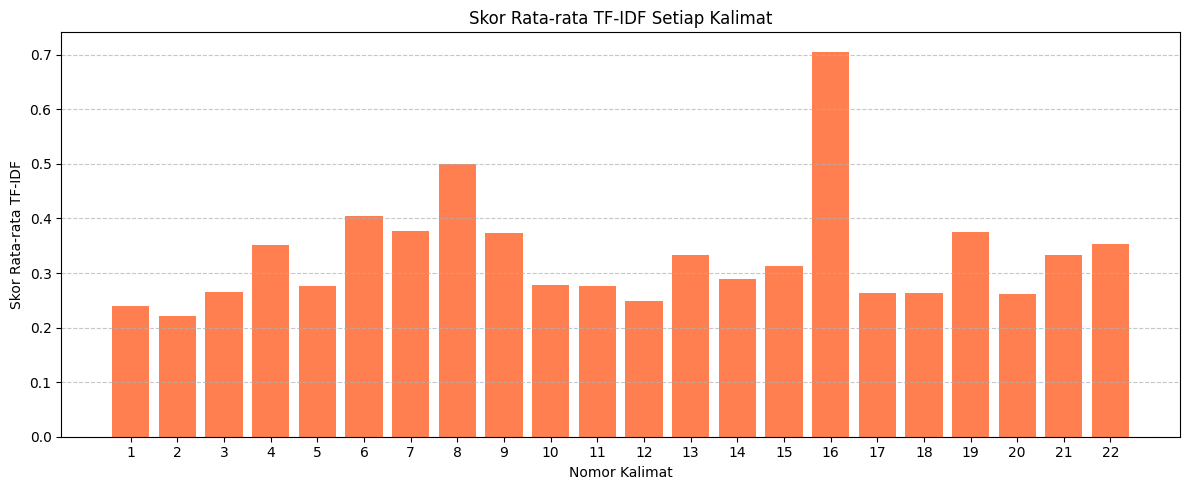


📌 PENJELASAN HISTOGRAM:
  - Bar yang lebih tinggi = kalimat mengandung kata yang lebih penting dan unik
  - Bar yang lebih rendah = kalimat mengandung kata yang lebih umum


In [6]:
sent_scores = []

print('📌 SKOR RATA-RATA TF-IDF SETIAP KALIMAT:')
print('=' * 80)

for idx, row in enumerate(tfidf_matrix):
    total_score = row.sum()
    num_words = len(row.data)
    avg_score = total_score / num_words if num_words > 0 else 0
    sent_scores.append(avg_score)
    print(f'  Kalimat {idx + 1}:')
    print(f'    🔹 Jumlah TF-IDF  : {total_score:.4f}')
    print(f'    🔹 Jumlah kata     : {num_words}')
    print(f'    🔹 Skor rata-rata  : {avg_score:.4f}')
    print('-' * 80)

# Visualisasi skor kalimat
plt.figure(figsize=(12, 5))
plt.bar(range(1, len(sent_scores) + 1), sent_scores, color='coral')
plt.xlabel('Nomor Kalimat')
plt.ylabel('Skor Rata-rata TF-IDF')
plt.title('Skor Rata-rata TF-IDF Setiap Kalimat')
plt.xticks(range(1, len(sent_scores) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print('\n📌 PENJELASAN HISTOGRAM:')
print('  - Bar yang lebih tinggi = kalimat mengandung kata yang lebih penting dan unik')
print('  - Bar yang lebih rendah = kalimat mengandung kata yang lebih umum')

## 6) Tentukan Threshold & Buat Ringkasan

Threshold dihitung dari rata-rata seluruh skor kalimat. Kalimat dengan skor di atas threshold akan dimasukkan ke dalam ringkasan.

In [7]:
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print(f'📌 THRESHOLD (Rata-rata Skor Kalimat): {threshold:.4f}')
print('=' * 80)

# Pilih kalimat yang skornya di atas threshold
summary_sentences = []
print('\n📌 KALIMAT YANG LOLOS THRESHOLD:')
print('-' * 80)
for idx, (score, sent) in enumerate(zip(sent_scores, sent_tokens)):
    if score >= threshold:
        summary_sentences.append(sent)
        print(f'  ✅ Kalimat {idx + 1} (skor: {score:.4f}): {sent[:80]}...')

print('\n' + '=' * 80)
print('📌 HASIL RINGKASAN:')
print('=' * 80)
summary = ' '.join(summary_sentences)
print(summary)
print('=' * 80)
print(f'\n📊 Jumlah kalimat asli    : {len(sent_tokens)}')
print(f'📊 Jumlah kalimat ringkasan: {len(summary_sentences)}')
print(f'📊 Rasio kompresi          : {len(summary_sentences)/len(sent_tokens)*100:.1f}%')

📌 THRESHOLD (Rata-rata Skor Kalimat): 0.3319

📌 KALIMAT YANG LOLOS THRESHOLD:
--------------------------------------------------------------------------------
  ✅ Kalimat 4 (skor: 0.3519): "We've shown over the past 12 months we are the best team in the world....
  ✅ Kalimat 6 (skor: 0.4042): "To win these five trophies – for me, the five biggest prizes available to us – ...
  ✅ Kalimat 7 (skor: 0.3774): I am so proud to have been a part of this and I can honestly say it's an honour ...
  ✅ Kalimat 8 (skor: 0.5000): I couldn't ask for better teammates."...
  ✅ Kalimat 9 (skor: 0.3733): It took just 40 seconds for Manchester City to take the lead....
  ✅ Kalimat 13 (skor: 0.3329): Foden then got on the scoresheet himself in the 72nd minute after a prodding hom...
  ✅ Kalimat 16 (skor: 0.7057): "As a manager it is what I am most proud of; that we are always there....
  ✅ Kalimat 19 (skor: 0.3755): "It is something no other English team has ever achieved, and we will always rem...
  ✅ Kal

## ✅ Kesimpulan

Pada notebook ini, kita telah berhasil:
1. Melakukan **tokenisasi kalimat** pada teks berbahasa Inggris
2. Menerapkan **TF-IDF** untuk menghitung bobot kata dengan penghapusan stopwords Inggris
3. Menghitung **skor kalimat** berdasarkan rata-rata TF-IDF
4. Menentukan **threshold** dan menghasilkan **ringkasan** otomatis

Metode ini merupakan pendekatan **ekstraktif** di mana kalimat-kalimat penting dipilih langsung dari teks asli berdasarkan bobot TF-IDF.